# Prostorová predikce čekacích dob na pohotovosti napříč spádovou oblastí poskytovatele pomocí PROC KRIGE2D



## Shrnutí

Provozní tým regionální zdravotnické sítě měří průměrnou čekací dobu na pohotovosti (ED) v minutách na každém obsazeném zařízení v metropolitní spádové oblasti a chce spojitou plochu čekacích dob, aby odhalil nedostatečně pokryté oblasti pro nové zařízení urgentní péče. Tento notebook vygeneruje syntetickou sadu **90 geokódovaných zařízení**, sestaví model **obyčejného krigingu** s nuggetem a interpoluje čekací doby na pohotovosti přes pravidelnou mřížku pokrývající spádovou oblast 50 × 50 km, přičemž vytvoří bodové predikce a směrodatné chyby krigingu v každém uzlu mřížky a ve třech navrhovaných lokalitách urgentní péče.

Napříč 90 zařízeními pozorovaná čekací doba v průměru činí **35,5 minuty** (rozsah 7,5 až 58,7). Kriging povrch reprodukuje tento střed téměř přesně (průměr v uzlech mřížky **35,55 minuty**) a pohybuje se od **16,1** v klidném jihovýchodě po **56,4** v přetíženém severozápadě, kde se shlukují uzly s nejvyšší predikovanou čekací dobou kolem centra dění v centru města. Ze tří kandidátských lokalit urgentní péče ta nejblíže centru města predikuje nejvyšší čekací dobu (**52,2 ± 7,3 minuty**), což z ní dělá nejsilnější případ podložený daty pro umístění zařízení.


## Zdroje dat

Všechna data jsou syntetická a generovaná přímo v prvním kroku DATA (`call streaminit(20260531)`). Nejsou použity žádné externí ani síťové soubory.

| Datová sada | Řádky | Proměnná | Typ | Popis |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | Num | Východní souřadnice zařízení v km (0-50) uvnitř mřížky metropolitní spádové oblasti |
| `ed_sites` | 90 | `north` | Num | Severní souřadnice zařízení v km (0-50) uvnitř mřížky metropolitní spádové oblasti |
| `ed_sites` | 90 | `site_id` | Char | Identifikátor zařízení (např. `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Num | Pozorovaná průměrná čekací doba na pohotovosti v minutách; prostorově korelovaná plocha kombinující gradient přetížení SZ-JV, nárůst v centru města a lokální šum |


## Prostorová predikce čekacích dob na pohotovosti pomocí PROC KRIGE2D

Regionální zdravotnický systém obsazuje **pohotovostní a urgentní ambulantní zařízení** rozmístěná napříč metropolitní spádovou oblastí 50 × 50 km. Každé zařízení hlásí svou **průměrnou čekací dobu na pohotovosti** (v minutách). Čekací doby jsou prostorově korelované: přetížené severozápadní městské jádro vykazuje vysoké hodnoty, zatímco okrajová jihovýchodní zařízení vykazují nižší. Síťové plánování potřebuje *spojitou* plochu čekacích dob s nejistotou, aby identifikovalo mezery, kde by nové zařízení urgentní péče uvolnilo nejvíce tlaku.

**PROC KRIGE2D** provádí dvourozměrný obyčejný kriging: pomocí modelu semivariogramu interpoluje naměřené čekací doby na mřížku lokalit a vrací jak predikci, tak směrodatnou chybu krigingu v každém uzlu. Provedeme:

1. Vygenerování realistické syntetické sady dat o zařízeních.
2. Profilaci pozorovaného rozložení čekacích dob.
3. Kriging se sférickým modelem plus nugget a prozkoumání plochy.
4. Přímou predikci ve třech kandidátských lokalitách urgentní péče.


## Krok 1 - Vygenerování syntetických dat o zařízeních

Rozmístíme 90 zařízení rovnoměrně napříč spádovou oblastí. Podkladová "skutečná" plocha čekacích dob kombinuje hladký velkoškálový trend (gradient přetížení SZ-na-JV plus centrální nárůst v centru města poblíž (15, 38)) s hladkým regionálním vírem, takže pole je skutečně prostorově autokorelované, nikoli čistý šum. Přidáme malý měřicí nugget, který napodobuje den ze dne se měnící variabilitu hlášení.


In [1]:
data ed_sites;
   CALL streaminit(20260531);
   DÉLKA site_id $6;
   OPAKUJ i = 1 TO 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Velkoškálový trend přetížení: vysoký v jádru SZ centra
         města, klesající směrem k okraji předměstí JV */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Centrální nárůst v centru města soustředěný poblíž (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* Hladký regionální vír pro vytvoření realistické autokorelace */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Lokální šum hlášení (měřicí nugget) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      KDYŽ wait_min < 3 PAK wait_min = 3;

      site_id = cats('FAC', put(i, z3.));
      VÝSTUP;
   KONEC;
   PONECHAT site_id east north wait_min;
SPUSTIT;

PROCEDURA TISK data=ed_sites(obs=10) noobs ŠTÍTEK;
   ŠTÍTEK site_id="ID zařízení" east="Východní souřadnice (km)"
         north="Severní souřadnice (km)" wait_min="Čekací doba (min)";
   NÁZEV 'Prvních 10 syntetických zařízení pohotovosti (souřadnice v km, čekací doba v minutách)';
   PROMĚNNÁ site_id east north wait_min;
SPUSTIT;


                 Prvních 10 syntetických zařízení pohotovosti (souřadnice v km, čekací doba v minutách)                 

   ID zařízení     Východní souřadnice (km)    Severní souřadnice (km)    Čekací doba (min)
FAC001                        42.1064239035              44.8746335392                 36.7
FAC002                        10.6189061789              14.5101311244                 36.2
FAC003                        48.9064287162                18.61727984                 17.7
FAC004                         45.555283186               43.264675772                 34.5
FAC005                        32.9816533373              24.7120124541                 32.5
FAC006                        31.1796232687              19.1168441231                 31.4
FAC007                        34.6664652019              35.2149577448                 39.2
FAC008                        40.5104234712               2.9588781811                 17.1
FAC009                         9.9213354522       


NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Krok 2 - Profilace pozorovaných čekacích dob

Před krigingem potvrďme, že je plocha rozumně rozložena. Rychlý souhrn `PROC MEANS` nám dá rozsah a centrální tendenci, kterou by kriging povrch měl reprodukovat. 90 zařízení má průměr **35,5 minuty** se směrodatnou odchylkou **10,6**, v rozsahu od **7,5** na nejklidnějším příměstském zařízení po **58,7** na nejpřetíženějším zařízení v centru města - široký, realistický rozsah pro interpolační cíl.


In [2]:
PROCEDURA PRŮMĚRY data=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   ŠTÍTEK wait_min="Čekací doba (min)";
   NÁZEV 'Pozorované rozložení čekací doby na pohotovosti napříč zařízeními';
   PROMĚNNÁ wait_min;
SPUSTIT;


                           Pozorované rozložení čekací doby na pohotovosti napříč zařízeními                            

                                                  The MEANS Procedure

 Variable  Label                      N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------
 wait_min  Čekací doba (min)         90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 ------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 3 - Obyčejný kriging se sférickým modelem

Příkaz `COORDINATES` pojmenovává prostorové osy, `PREDICT VAR=` pojmenovává analyzovanou proměnnou a nastavuje vyhledávací okolí a `MODEL` dodává semivariogram. Používáme **sférickou** formu (standardní volba, kdy korelace klesá na nulu při konečném dosahu), s:

- `SCALE=120` - dílčí práh (variabilita vysvětlená prostorovou strukturou),
- `RANGE=18` - korelace dosáhne pozadí zhruba na 18 km,
- `NUGGET=14` - měřicí/hlásicí diskontinuita při nulové vzdálenosti.

Interpolujeme na pravidelnou mřížku **9 × 9 = 81 uzlů** pokrývající celou spádovou oblast (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - dostatečně hrubou pro přímé shrnutí a seřazení každého uzlu, dostatečně jemnou pro zmapování struktury. `OUTEST=` zachytí predikce a směrodatné chyby v uzlech mřížky; `OUTNBHD=` zaznamená, kolik zařízení vstoupilo do každého lokálního výpočtu. `PLOTS=` vyžádá mapu pozorovaných dat a konturu predikce vyplněnou podle směrodatné chyby.


                           Pozorované rozložení čekací doby na pohotovosti napříč zařízeními                            

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


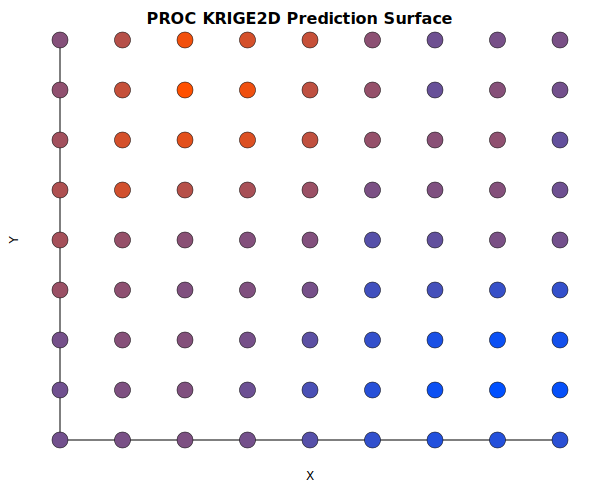

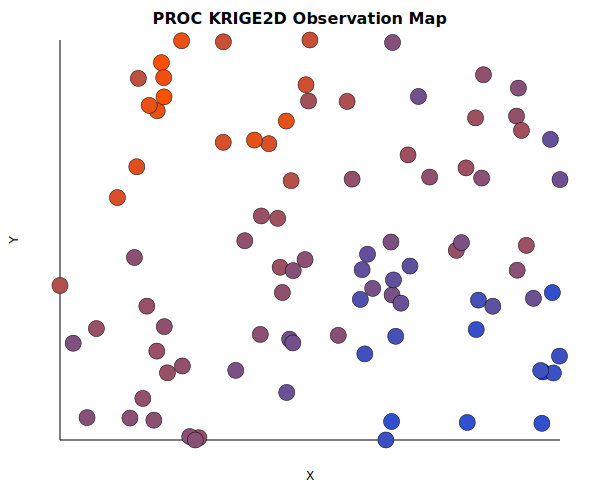

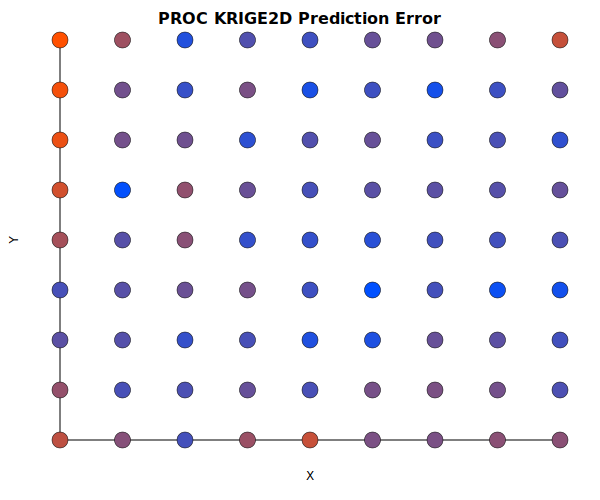

In [3]:
PROCEDURA krige2d data=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   ŠTÍTEK east="Východní souřadnice (km)" north="Severní souřadnice (km)"
         wait_min="Čekací doba (min)";
   NÁZEV 'Obyčejný kriging čekacích dob na pohotovosti - sférický model';
   COORDINATES XC=east YC=north;
   predict var=wait_min radius=20 minpoints=10 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 TO 50 by 6 y=0 TO 50 by 6;
SPUSTIT;


## Krok 4 - Prozkoumání kriging povrchu

Datová sada `OUTEST=` obsahuje jeden řádek na uzel mřížky s predikovanou čekací dobou (`estimate`) a její směrodatnou chybou krigingu (`stderr`). Shrneme plochu a označíme uzly s nejvyšší predikcí - kandidátské zóny, kde by nové zařízení urgentní péče uvolnilo nejvíce tlaku.

Průměr kriging povrchu (**35,55 minuty**) sleduje pozorovaný průměr zařízení (35,5) téměř přesně, což je kontrola zdravého rozumu, že obyčejný kriging je nevychýlený. Predikce se pohybují od **16,1** v řídkém jihovýchodě po **56,4** v přetíženém severozápadě; směrodatné chyby se pohybují od **5,1** tam, kde jsou zařízení hustá, po **11,2** v řídce vzorkovaných rozích. Šest nejteplejších uzlů leží v kvadrantu SZ kolem (12-18, 36-48), přesně na nárůstu v centru města zabudovaném do dat.


In [4]:
PROCEDURA PRŮMĚRY data=krige_sph n mean MIN MAX maxdec=2;
   ŠTÍTEK ESTIMATE="Predikce (min)" stderr="Směrodatná chyba";
   NÁZEV 'Souhrn kriging povrchu (predikované čekací minuty a směrodatná chyba)';
   PROMĚNNÁ ESTIMATE stderr;
SPUSTIT;

PROCEDURA ŘADIT data=krige_sph out=hot_nodes;
   PODLE SESTUPNĚ ESTIMATE;
SPUSTIT;

PROCEDURA TISK data=hot_nodes(obs=6) noobs ŠTÍTEK;
   ŠTÍTEK x="Souřadnice X" y="Souřadnice Y" ESTIMATE="Predikce (min)"
         stderr="Směrodatná chyba";
   NÁZEV 'Šest uzlů mřížky s nejvyšší predikovanou čekací dobou na pohotovosti';
   PROMĚNNÁ x y ESTIMATE stderr;
SPUSTIT;


                         Souhrn kriging povrchu (predikované čekací minuty a směrodatná chyba)                          

                                                  The MEANS Procedure

 Variable  Label                     N        Mean     Minimum     Maximum
 -------------------------------------------------------------------------
 ESTIMATE  Predikce (min)           81       35.55       16.07       56.38
 STDERR    Směrodatná chyba         81        7.38        5.06       11.20
 -------------------------------------------------------------------------

                          Šest uzlů mřížky s nejvyšší predikovanou čekací dobou na pohotovosti                          

 Souřadnice X   Souřadnice Y  Predikce (min)    Směrodatná chyba
           12             42   56.3838526129        6.3860887297
           12             48    54.379464215         5.876759721
           18             42     53.81777091        8.0028060667
           12             36   51.9499223116     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Krok 5 - Predikce v konkrétních kandidátských lokalitách

Síťové plánování má tři navrhované lokality urgentní péče. Krigujeme přímo v každém bodě tím, že jej dodáme jako jednouzlovou mřížku (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), čímž plánovačům poskytneme predikovanou čekací dobu a její směrodatnou chybu krigingu na přesné souřadnici.

Kandidát blízko centra města, **(14, 37)**, vrací nejvyšší predikovanou čekací dobu - **52,2 ± 7,3 minuty** - což potvrzuje, že by absorboval poptávku z nejvytíženějších pohotovostí. Jihovýchodní kandidát **(32, 12)** leží v klidném příměstském koutě na **22,0 ± 6,2** a severovýchodní kandidát **(42, 44)** je uprostřed rozsahu na **36,4 ± 5,9**. Pouze podle predikované čekací doby je kandidát v centru města nejsilnějším případem podloženým daty.


In [5]:
PROCEDURA krige2d data=ed_sites outest=cand_dt PLOTS=none;
   NÁZEV 'Kandidát A - centrum města (14, 37)';
   COORDINATES XC=east YC=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 TO 14 by 1 y=37 TO 37 by 1;
SPUSTIT;

PROCEDURA krige2d data=ed_sites outest=cand_se PLOTS=none;
   NÁZEV 'Kandidát B - příměstský jihovýchod (32, 12)';
   COORDINATES XC=east YC=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 TO 32 by 1 y=12 TO 12 by 1;
SPUSTIT;

PROCEDURA krige2d data=ed_sites outest=cand_ne PLOTS=none;
   NÁZEV 'Kandidát C - severovýchodní okraj (42, 44)';
   COORDINATES XC=east YC=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 TO 42 by 1 y=44 TO 44 by 1;
SPUSTIT;

data candidates;
   NASTAVIT cand_dt cand_se cand_ne;
SPUSTIT;

PROCEDURA TISK data=candidates noobs ŠTÍTEK;
   ŠTÍTEK x="Souřadnice X" y="Souřadnice Y" ESTIMATE="Predikce (min)"
         stderr="Směrodatná chyba";
   NÁZEV 'Predikované čekací doby na pohotovosti ve třech kandidátských lokalitách urgentní péče';
   PROMĚNNÁ x y ESTIMATE stderr;
SPUSTIT;


                          Šest uzlů mřížky s nejvyšší predikovanou čekací dobou na pohotovosti                          

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                          Šest uzlů mřížky s nejvyšší predikovanou čekací dobou na pohotovosti                          

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Interpretace výsledků

- **Kriging povrch reprodukuje strukturu přetížení spádové oblasti.** Sférický model obyčejného krigingu interpoluje hladké pole čekacích dob, jehož průměr v uzlech mřížky (35,55 min) odpovídá pozorovanému průměru zařízení (35,5 min), přičemž nejvyšší predikované čekací doby - až 56,4 minuty - se soustřeďují v kvadrantu SZ kolem nárůstu v centru města poblíž (15, 38), který jsme zabudovali do syntetických dat. Tato shoda je kontrolou zdravého rozumu, že se model chová správně.
- **Směrodatné chyby lokalizují jistotu.** Směrodatná chyba krigingu se pohybuje od 5,1 minuty tam, kde jsou zařízení hustá, po 11,2 v řídce vzorkovaných rozích spádové oblasti. Plánovači by měli k predikcím v zónách s vysokou `stderr` přistupovat opatrně; jsou to zároveň oblasti, kde by přidání zařízení nejvíce zlepšilo jak budoucí pokrytí, tak budoucí měření.
- **Bodové predikce podporují rozhodnutí o umístění.** Kriging tří kandidátských lokalit přímo promění plochu v použitelnou tabulku. Kandidát v centru města (14, 37) vykazuje nejvyšší predikovanou čekací dobu (52,2 min) se střední směrodatnou chybou (7,3), což z něj dělá nejsilnější případ podložený daty pro nové zařízení urgentní péče, které by odlehčilo nejvytíženější pohotovosti; příměstský jihovýchodní kandidát (32, 12) leží v koutě s nízkou poptávkou (22,0 min) a severovýchodní okrajový kandidát (42, 44) je uprostřed rozsahu (36,4 min).

V praxi by parametry semivariogramu (`SCALE`, `RANGE`, `NUGGET`) byly odhadnuty empiricky pomocí PROC VARIOGRAM a poté předány do KRIGE2D - buď jako explicitní hodnoty, jak je uvedeno zde, nebo automaticky pomocí `RESTORE` z item store procedury VARIOGRAM.
